# Assignment 2: Discrete and Continuous Probability Models
Authored by Kristian M. P. Dashnaw (344849) & Katrine B. Aamand (344848) <br>
Based on assignment 2 description (https://rbrooksdk.github.io/STA1_26/assignments/assignment_02_discrete_and_continuous_models/#preparation-resources-and-ai)

## Table of Contents

1. **Part 1 — Cooling-unit failures: a finite random variable**
    - a. PMF Validity, Support, and Random Variable vs. Observed Value
    - b. PMF/CDF Table and Probability Calculations
    - c. PMF Bar Chart and CDF Step Plot
    - d. Expectation, Variance, and Standard Deviation
2. **Part 2 — Repeated-event count models**
    - Late Supplier Deliveries: Binomial
      - a. Model Justification and Assumptions
      - b. Probability Calculations with SciPy
      - c. Mean and Standard Deviation
    - Production Stoppages: Poisson
      - a. Model, Parameter, Support, and Single-Shift Probabilities
      - b. Rate Scaling to 24 Hours and Assumption Discussion
3. **Part 3 — Uniform and normal models**
    - Sensor Polling Delay: Uniform
      - a. SciPy Model, PDF and CDF Plots
      - b. Probabilities, Moments, and 95th Percentile
    - Concrete Strength: Normal Working Model
      - a. Descriptive Statistics and Parameter Fitting
      - b. Density Histogram, Fitted PDF, and QQ-Plot
      - c. Model Probabilities, Percentile, z-Score, and Empirical Comparison
4. **Part 4 — Service restoration: an exponential working model**
    - a. Descriptive Statistics and Density Histogram
    - b. Fitting the Exponential Model
    - c. Graphical Model Assessment: ECDF and QQ-Plot
    - d. Model Probabilities, Median, and 90th Percentile
    - e. Conditional Probability and Memorylessness
5. **Part 5 — AI Use and Conclusion**
    - a. AI-Use Statement
    - b. Overall Conclusion

In [8]:
#Imports:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson
from math import factorial

# Load the data files:
print("\nConcrete_Strength.csv, first 5 rows:")
concreteStrengthData_unmodified = pd.read_csv('data/assignment02_concrete_strength.csv', delimiter = ',')
display(concreteStrengthData_unmodified.head(5))

print("\n\nService_Repairs.csv, first 5 rows:")
serviceRepairsData_unmodified = pd.read_csv('data/assignment02_service_repairs.csv', delimiter = ',')
display(serviceRepairsData_unmodified.head(5))


Concrete_Strength.csv, first 5 rows:


,specimen_id,strength_mpa
0,1,43.56
1,2,40.05
2,3,42.32
3,4,38.40
4,5,42.44




Service_Repairs.csv, first 5 rows:


,incident_id,repair_time_min
0,1,80.99
1,2,2.46
2,3,30.32
3,4,38.91
4,5,410.66


<br><br><br>

---

<br><br>

## Part 1: Cooling-unit failures: a finite random variable
Let $X$ be the number of cooling units that fail during a weekly maintenance window. The engineering model is

|      $x$ |    $0$ |    $1$ |    $2$ |    $3$ |    $4$ |
|---------:|-------:|-------:|-------:|-------:|-------:|
| $P(X=x)$ | $0.58$ | $0.26$ | $0.10$ | $0.04$ | $0.02$ |

<br>

### a. Verify that the table is a valid PMF, state the support, and distinguish the random variable $X$ from an observed value $x$.

In [ ]:
# Kristian

A Probability Mass Function (PMF) is valid if and only if:
```markdown
1. p_X(x) >= 0, for every x, and
2. The probabilities over all values in the support sum to one.
```

#### The support:
Before we evaluate these requirements, let's define the support:

The support is of a Discrete Random Variable is defined as:

```markdown
supp(X) = {x ∈ R : P(X = x) > 0}
```

X is our **discrete random variable** with observed values x belonging to a real number and where the probability P(X = x) is larger than zero. That resolves to this set, supp(X) = { 0, 1, 2, 3, 4 }, as specified in the table.

<br>

#### Requirement 1: $p_X(x) >= 0$, for every x:
From the definition of a **probability mass function**, we are given that $p_X(x) = P(X = x)$, where the values outside the support of X each resolve to $p_X(x) = 0$.

Values in the support for x ∈ supp(X) = { 0, 1, 2, 3, 4 }, the tables gives these probabilities 0.58, 0.26, 0.10, 0.04, 0.02, which are all positive.
For values outside the support, these are assigned the probability of 0.

Since $p_X(x)$ is either positive or zero for every x ∈ R, we conclude that Requirement 1 is satisfied.

<br>

#### Requirement 2: Probabilities over all values in the support sum to one:
The probabilities of values in the support of X, are given as $0.58 + 0.26 + 0.10 + 0.04 + 0.02 = 1.00$

Since summing these together equals 1.0 exactly, we conclude that requirement 2 is also satisfied.

#### Conclusion: The provided table is a valid PMF, since both requirements are satisfied.

<br>

#### Distinguishing the random variable X from the observed value x:
X (uppercase) is the **random variable** (I.e. the unknown number of cooling units that will fail during a weekly maintenance window). It is discrete because it's countable - and in this case also finite, defined with 5 values { 0, 1, 2, 3, 4 }.

x (lowercase) is the **observed value** that X can take. Understanding this, if 1 cooling unit fails during the weekly maintenance, the observed  value is x = 1. Thus, the expression becomes $P( X = 1) = 0.26$, when extrapolated by the given table.


<br><br>
### b. Construct a table containing $x$, $p_X(x)$, and $F_X(x)$. Use it to calculate $P(X=2)$, $P(X\le1)$, $P(X\ge2)$, and $P(1<X\le3)$.

In [ ]:
# Kristian

Constructing the table, we need to understand what $F_X(x)$ exactly is. $F_X(x)$ is defined as the **cumulative distribution function** (CDF) of a random variable X, such that $F_X(x)$ = $P(X <= x), x ∈ R$. So basically the probability that the variable X is less than or equal to a given value x.

Based on this, we can build the following table showing the relations between $x$, $p_X(x)$ and $F_X(x)$, based on the given engineering model.

| $x$ | $p_X(x)$ | $F_X(x)$ |
|:---:|:--------:|:--------:|
| $0$ |   0.58   |   0.58   |
| $1$ |   0.26   |   0.84   |
| $2$ |   0.10   |   0.94   |
| $3$ |   0.04   |   0.98   |
| $4$ |   0.02   |   1.00   |

<br>

#### Calculating $P(X=2)$:
From the **probability mass function** we know that $p_X(x) = P(X = x)$.

We can therefore determine $P(X=2)$ to be

$p_X(2) = P(X=2) = 0.10$

<br>

#### Calculating $P(X\le1)$:
Here we want to determine the probability associated with an observed outcome where either 0 or 1 cooling unit fails during the weekly maintenance. Thus we add the probabilities for x = 0 and x = 1, to get the solution.

$P(X\le1) = P(X=0) + P(X=1) = 0.58 + 0.26 = 0.84$,

Alternatively we could also just read $F_X(1)$, which also equals 0.84.

<br>

#### Calculating $P(X\ge2)$:
Here we want to determine the probability associated with an observed outcome where 2 or more cooling units fail during the weekly maintenance. Thus we add the probabilities for x = 2, x = 3 and x = 4, to get the solution.

$P(X\ge2) = P(X=2) + P(X=3) + P(X=4) = 0.10 + 0.04 + 0.02 = 0.16$,

Alternatively we could use $F_X(4) - F_X(1)$ to arrive at the same answer: $F_X(4) - F_X(1) = 1.00 - 0.84 = 0.16$

<br>

#### Calculating $P(1<X\le3)$:
Here we want to determine the probability associated with an observed outcome where more than 1 and less than 4 cooling units fail during the weekly maintenance. Thus we add the probabilities for x = 2 and x = 3, to get the solution.

$P(1<X\le3) = P(X=2) + P(X=3) = 0.10 + 0.04 = 0.14$,

Alternatively we could use $F_X(3) - F_X(1)$ to arrive at the same answer: $F_X(3) - F_X(1) = 0.98 - 0.84 = 0.14$

<br><br>
### c. Plot the PMF as a bar chart and the CDF as a step plot. Explain the meaning of the height at each value in both plots.

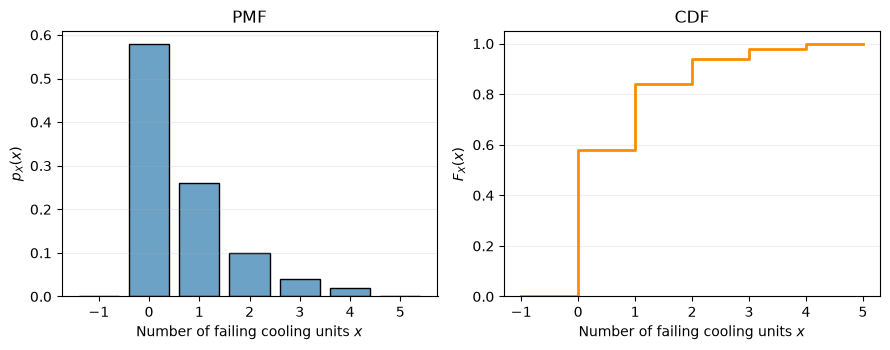

In [19]:
# Kristian

k = np.arange(-1, 6)
pmf = np.array([0, 0.58, 0.26, 0.10, 0.04, 0.02, 0])
cdf = np.cumsum(pmf)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
axes[0].bar(k, pmf, color="#6CA2C6", edgecolor="black")
axes[0].set_xticks(k)
axes[0].grid(axis='y', alpha=0.2)
axes[0].set_xlabel("Number of failing cooling units $x$")
axes[0].set_ylabel(r"$p_X(x)$")
axes[0].set_title("PMF")

axes[1].step(k, cdf, where="post", color="#FF8C00", linewidth=2)
axes[1].set_xticks(k)
axes[1].grid(axis='y', alpha=0.2)
axes[1].set_xlabel("Number of failing cooling units $x$")
axes[1].set_ylabel(r"$F_X(x)$")
axes[1].set_title("CDF")
axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

### PMF Interpretation:
The Probability Mass Function (PMF) is plotted as a bar chart based on the provided engineering model. Reading the bar chart left to right, we see that when $x = 0$, that the bars height is $\approx0.6$, indicating that the probability of there being exactly 0 failing cooling units during a weekly maintenance is about $\approx60\%$, matching the 0.58 given in our engineering model.

Interpreting the next bar, where $x = 1$, we see the height reach about $0.25$, indicating that the probability of there being exactly 1 failing cooling unit during a weekly maintenance is about $\approx25\%$, again matching the 0.26 given in the engineering model.

This shows that the height of each bar at x is $p_X(x) = P(X = x)$, the probability that exactly x cooling units fail during weekly maintenance. The height of all bars combined sums to 1, and we see that the majority of the probable failures lie between 0 and 1 cooling units.

### CDF Interpretation
The cumulative distribution function (CDF) is plotted as a step plot based on the calculated cumulative probabilities from the table in 1b.

Reading it left to right, we see that when $x = 0$ the cumulative probability of exactly 0 units failing during a weekly maintenance is $\approx0.6$ or $\approx60\%$.

Stepping to $x = 1$, we see that the cumulative probability that at most 1 cooling unit fails is $\approx0.85$ or $\approx85\%$, which is consistent with this value being the cumulative probabilities from the first 2 bars (from the left) in the PMF bar chart. The exact value here is $0.58 + 0.26 = 0.84$.

Stepping to $x = 2$, we see the cumulative probability rise to $\approx0.95$ or $\approx95\%$, matching the sum of the first 3 bars (from the left). The exact value here is $0.58 + 0.26 + 0.10 = 0.94$

Overall, this shows that the height at x is $F_X(x) = P(X \le x)$, the probability that at most x units fail during a weekly maintenance window. The step plot also shows that probability is 0 for x < 0, remaining flat between values in the support {0, 1, 2, 3, 4}, and only jumping at each increment of a value in the support, before flattening out above 4 where the probability reaches 1. We also see that each jump equals the PMF bar at the corresponding point.

#### Conclusion
The PMF shows the probability associated with the exact specific value x. This is useful when you need to evaluate probabilities associated with specific outcomes.
The CDF shows the probability associated with a given value x **and** all values of x less than the specified value, i.e. $F_X(x) = P(X \le x)$. This is useful when you need to evaluate probabilities associated with boundaries or ranges (such as lower 90%, upper 10%, etc.).

<br><br>
### d. Calculate and interpret $E[X]$, $\operatorname{Var}(X)$, and $\operatorname{SD}(X)$.

In [ ]:
# TODO: Kristian

<br><br><br>

---

<br>

## Part 2: Repeated-event count models

### Late supplier deliveries: binomial

A project expects 30 deliveries. Each is modelled as late with probability 0.12 independently of the others. Let $B$ be the number of late deliveries.

<br><br>
#### a. Justify $B\sim\operatorname{Bin}(30,0.12)$. Identify the Bernoulli trial and discuss fixed $n$, constant $p$, independence, and one realistic violation.

To model the number of late deliveries, we need a distribution that describes a count of events among a fixed number of repeated trials. 
The binomial distribution is made for exactly this, but only if the experiment satisfies certain conditions. 

We let B be the number of late deliveries among the 30 deliveries. B is a discrete random variable, since it can only take whole-number values, and its support is: $\{0, 1, \dots, 30\}$.

The building block of the binomial distribution model is the Bernoulli trial, which is a single trial with two possible outcomes = success or failure, 1 or 0. In this case one trial is one delivery and we code its outcome using the variable $X_i$, where $X_i = 1$ if the delivery is late and $X_i=0$ if the delivery arrives on time. Calling a late delivery a success might seem counterintuitive, since a late delivery is undesirable, but success is only a label for the event we are counting. With a probability of $p=0.12$ of a delivery being late, each delivery is modelled as $X_i \sim \operatorname{Bernoulli}(0.12)$, so it's on time with probability 0.88. The total number of deliveries is then the sum of these indicators: $B = X_1 + X_2 + \dots + X_30$, and if the four conditions of a binomial experiment hold, this sum follows: $B \sim \operatorname{Bin}(30, 0.12)$

The conditions of a binomial experiments are: 
- Each trial has exactly two outcomes: this holds up as long as a delivery "being late" is clearly defined. F.ex. a delivery arriving after the agreed delivery date, making it possible to classify every delivery as either late or on time 
- The experiment must have a fixed number of trials $n$. This matters because $n$ determines both the support $\{0, \dots, n\}$ and the shape of the PMF. If the number of deliveries where random, B would no longer be binomial. The description states the the project expects 30 deliveries, which implies a certain amount of uncertainty. We therefore treat $n = 30$ as fixed for the purpose of the model. 
- The experiment must have a constant success probability p, meaning that every delivery has the same probability 0.12 of being late. In practice, the probability of being late may vary between suppliers, transport routes, seasons(holidays or weather conditions). 
- The fourth condition is independence, if one delivery is late it shouldn't change the probability that another is late. This is probably the most questionable conditions of them all. A realistic violation could occur when several deliveries are routed through the same port or with the same carrier. If this carrier is hit with strike, a congestion or bad weather conditions can delay multiple deliveries at once, since they share a common cause. This creates clusters of late deliveries, which the binomial model doesn't account for. As a consequence the model would underestimate the probability of many late deliveries and the true variability would be larger than the binomial variance $ \operatorname{np}(1-p)$. 

In conclusion, $B \sim \operatorname{Bin}(30, 0.12)$ is a reasonable working model under the stated assumptions, and it gives a simple and transparent description of the number of late deliveries. However, probabilities of late deliveries should be interpreted with caution if deliveries are likely to share common causes of delays. 

<br><br>
#### b. Use SciPy to calculate $P(B=3)$, $P(B\le4)$, and $P(B\ge5)$. For $P(B=3)$, also show the binomial formula and explain $\binom{n}{k}$. For the upper tail, explain the correct survival-function argument.

In this section, we use the binomial model $B \sim \operatorname{Bin}(30, 0.12)$ from 2a to calculate three probabilities. Each on calls for a different function: 
    - PMF, for an exact value
    - CDF, for a lower tail
    - SF, and the survival function for an upper tail. 

For $P(B=3)$ we also compute the probability by hand with the binomial formula to show how the result is built up. The binomial formula looks like this: 
$P(B = b) = \binom{n}{b} p^{b} (1-p)^{n-b}, \quad b = 0, 1, \dots, 30$

The binomial coefficient $\binom{n}{b}$ counts the number of ways this scenario can occur. 
In this case it means that $\binom{30}{3} = 4060$ is the number of ways to choose which 3 of the 30 deliveries are late. Each of the 4060 combinations has the same probability: $0.12^3 * 0.88^{27}$, because the deliveries are independent and p is constant. 

In [ ]:
# Katrine
n = 30 # number of trials / deliveries 
p = 0.12 # probability that a single delivery is late (success)

def C(n, k): 
    """Binomial coefficient: the number of ways to choose which k of the
    n trials are successes, C(n, k) = n! / (k! * (n - k)!)."""
    return factorial(n) // (factorial(k) * factorial(n - k))

# P(B=3)
k = 3

# 1) Using SciPy's PMF
p_scipy = binom.pmf(k, n, p)

# 2) Using the binomial formula by hand:
#    C(n, k)       -> number of ways to place the 3 late deliveries among 30
#    p**k          -> probability that those 3 specific deliveries are late
#    (1-p)**(n-k)  -> probability that the other 27 deliveries are on time
p_manual = C(n, k) * p**k * (1 - p)**(n - k)

print(f'C({n}, {k}) = {C(n, k)}')
print(f'P(B = 3), SciPy PMF:        {p_scipy:.4f}')
print(f'P(B = 3), binomial formula: {p_manual:.4f}')

# P(B≤4) 
k = 4
print(f'P(B ≤ 4) = {binom.cdf(k, n, p):.4f}')

# P(B≥5)
k = 5
print(f'P(B ≥ 5) = {binom.sf(k-1, n, p):.4f}')

# sf(k) = P(B > k), so P(B >= 5) = P(B > 4) = sf(4)
print(f'Check: {binom.cdf(4, n, p) + binom.sf(4, n, p):.4f}')



C(30, 3) = 4060
P(B = 3), SciPy PMF:        0.2224
P(B = 3), binomial formula: 0.2224
P(B ≤ 4) = 0.7118
P(B ≥ 5) = 0.2882


#### Results 
$P(B=3) = 0.2224$. The PMF, probability mass function, returns the probability of exactly one value, in this case 3. Which means that there are 22.24% chance of exactly 3 out of 30 deliveries are late. The manual way of calculating the binomial formula looks like this: $P(B=3) = \binom{30}{3} \cdot 0.12^{3} \cdot 0.88^{27} = 4060 \cdot 0.001728 \cdot 0.0317 \approx 0.2224$. Which resulted in the same result as the sciPy evaluated $ \operatorname{binom.pmf}(k, n, p)$. 

$P(B \le 4) = 0.7118$. The CDF, cumulative distribution function, gives us an accumulated probability, in this case 71.18%, four or fewer deliveries are late. 

$P(B \ge 5) = 0.2882$ To calculate an upper-tail probability, we use the survival function, which is the complement of the CDF: $ \operatorname{sf}(k) = P(B > k) = 1 − F(k)$. The survival function therefore gives the probability of values strictly greater than k, so k itself is not included. Since B can only take integer values, "at least 5" is the same event as "more than 4", that is $P(B ≥ 5) = P(B > 4)$, and the correct argument is $ \operatorname{sf}(4)$. Using $ \operatorname{sf}(5)$ would be a common mistake. It returns $P(B > 5) = P(B ≥ 6) = 0.1431$, which leaves out $P(B = 5) = 0.1451$ and roughly halves the result. As a check, $P(B ≤ 4) + P(B ≥ 5) = 0.7118 + 0.2882 = 1$, since the two events are complementary and together cover the entire support.

In practical terms, the most likely single outcome is around 3 late deliveries, and there is about a 71% chance that at most 4 of the 30 deliveries are late. However, there is still roughly a 29% chance, more than one in four, that five or more deliveries are late, which is a substantial risk for project planning. This upper-tail probability should be interpreted with caution. As discussed in 2a, deliveries that share a common cause of delay, such as the same port or carrier, violate the independence assumption. In that case, the binomial model would underestimate the probability of many late deliveries, so the true risk of five or more late deliveries may be higher than 29%.

<br><br>
#### c. Calculate and interpret the mean and standard deviation.

In [ ]:
# TODO: Katrine

<br><br>
### Production stoppages: Poisson
Short stoppages are modelled as a Poisson process with mean 1.6 per 8-hour shift. Let $Y$ be the count during one shift.

#### a. State the model, parameter, support, mean, and variance. Calculate $P(Y=0)$ and $P(Y\ge3)$ for one shift.

In [ ]:
# TODO: Kristian

<br><br>
#### b. Scale the expected count and calculate the probability of at least three stoppages in 24 hours. Discuss the stable-rate and independent-event assumptions.

In [ ]:
# TODO: Kristian

<br><br><br>

---

<br>

## Part 3: Uniform and normal models

### Sensor polling delay: uniform

A monitoring device polls a sensor once every 12 seconds. An event is assumed to occur at a random point in the cycle, so the delay $D$ until the next poll is modelled as $D\sim\operatorname{Uniform}(0,12)\$.

<br><br>
#### a. Create the SciPy model using the correct location and scale. Plot its PDF and CDF and explain the support, constant density, and why $P(D=d)=0$.

In [ ]:
# TODO: Katrine

<br><br>
#### b. Calculate $P(D\le3)$, $P(4<D<9)$, $P(D>10)$, the mean, standard deviation, and 95th percentile.

In [ ]:
# TODO: Katrine

<br><br><br>
### Concrete strength: normal working model

The file [assignment02_concrete_strength.csv](../data/assignment02_concrete_strength.csv) contains 160 compressive-strength measurements. Treat the generating parameters as unknown.

<br>

#### a. Report $n$, mean, median, and sample standard deviation. Fit $N(\hat\mu,\hat\sigma^2)$ and explain why SciPy receives $\hat\sigma$, not $\hat\sigma^2$, as `scale`.

In [ ]:
# TODO: Kristian

<br><br>
#### b. Plot a density histogram with the fitted PDF and create a normal QQ-plot. Discuss symmetry, tails, unusual observations, and model adequacy.

In [ ]:
# TODO: Kristian

<br><br>
#### c. From the fitted model, calculate $P(X<35)$, $P(38<X<46)$, the 95th percentile, and the $z$-score of 35 MPa. Compare the first two model probabilities with empirical proportions.

In [ ]:
# TODO: Kristian

<br><br><br>

---

<br>

## Part 4: Service restoration: an exponential working model
The file [assignment02_service_repairs.csv](../data/assignment02_service_repairs.csv) contains 180 restoration times from independent service incidents. Treat the rate as unknown.


<br>

#### a. Report $n$, mean, median, sample standard deviation, minimum, and maximum. Plot a density histogram and describe the shape.

In [ ]:
# TODO: Katrine

<br><br>
#### b. Fit an exponential model using $\hat\lambda=1/\bar x$. State its fitted rate, mean, variance, and SciPy scale and add the fitted PDF to the histogram.

In [ ]:
# TODO: Katrine

<br><br>
#### c. Compare empirical and fitted distributions using an empirical CDF with fitted CDF or an exponential QQ-plot. Discuss model strengths and limitations.

In [ ]:
# TODO: Katrine

<br><br>
#### d. Calculate and interpret $P(T\le30)$, $P(T>120)$), the median, and the 90th percentile. Compare the two model probabilities with empirical proportions.

In [ ]:
# TODO: Katrine

<br><br>
#### e. Calculate $P(T>150\mid T>60)$ as both a ratio of survival probabilities and the probability of waiting an additional 90 minutes. Explain the memoryless and constant-rate assumptions.

In [ ]:
# TODO: Katrine

<br><br><br>

---

<br>

## Part 5: AI-Use and Conclusion
### AI-use
State which AI tools you used, what they contributed, what you changed or rejected, and how you verified the result. A short paragraph or table is sufficient. If AI produced most of the code or text, state this honestly.

#### In part 1...
```TODO: Kristian```
- Tasks were solved manually first, using the course book and course material as reference. When solved, AI was used to provide feedback on the written solutions.
- AI was also used for the Python syntax.

##### What changed/got rejected:
- Supporting explanations were made clearer, typos identified and fixed and some mix-ups in my explanations concerning the use of x vs X were rectified.

##### How I checked that the final work was correct:
...
<br><br>

#### In part 2...
```TODO: Kristian + Katrine```
...

##### What changed/got rejected:
...

##### How I checked that the final work was correct:
...
<br><br>

#### In part 3...
```TODO: Kristian + Katrine```
...

##### What changed/got rejected:
...

##### How I checked that the final work was correct:
...
<br><br>

#### In part 4...
```TODO: Katrine```
...

##### What changed/got rejected:
...

##### How I checked that the final work was correct:
...

_____________

### Overall conclusion
Write approximately 150–250 words comparing the probability models used in the assignment. Explain how support, mechanism, parameterisation, and graphical model assessment determine whether a calculated probability is useful.

Only use Sessions 3–4. Do not use sampling distributions, confidence intervals, hypothesis tests, bootstrap procedures, or later methods.


## Submission checklist

- [ ] Every random variable, event, support, and parameter is defined.
- [ ] PMF, PDF, CDF, SF, and PPF are used appropriately.
- [ ] Binomial and Poisson assumptions are discussed.
- [ ] SciPy scale parameters are correct.
- [ ] Fitted normal and exponential models are assessed graphically.
- [ ] Model probabilities and empirical proportions are distinguished.
- [ ] Part 5 contains the AI-use statement and conclusion.
- [ ] All code is executed and output is visible.